In [1]:
import pandas as pd

In [3]:
import pandas as pd

df = pd.read_csv("mabel.txt", header=None, on_bad_lines='skip', encoding='utf8')

In [4]:
df=df.drop(0)
df.columns=['Date','Chat']
Message=df["Chat"].str.split("-",n=1,expand=True)
df["Time"]=Message[0]
Message1=Message[1].str.split(":",n=1,expand=True)
df["Name"]=Message1[0]
df["Chat"]=Message1[1]
df=df[["Date","Time","Name","Chat"]]
df

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?
7,05/12/19,1:43 pm,AR❤,Yes Mam
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working
9,05/12/19,1:43 pm,AR❤,Yeah mam
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 1 to 50
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    50 non-null     object
 1   Time    50 non-null     object
 2   Name    50 non-null     object
 3   Chat    50 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB


In [7]:
!pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------------- ----- 1.3/1.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.2 MB/s  0:00:00

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   ------------- -------------------------- 1/3 [regex]
   ------------- ------------

In [8]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\Vino
[nltk_data]     Nandu\AppData\Roaming\nltk_data...


True

In [9]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [10]:
sia = SentimentIntensityAnalyzer()

In [11]:
dataset=df

In [12]:
dataset.dropna(inplace=True)

In [14]:
senti=sia.polarity_scores(dataset['Chat'][4])

In [15]:
senti

{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.296}

In [18]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

def sentimentalAnalysis(data, columnname):

    data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(str(commentText)))

    data['compound'] = data['scores'].apply(lambda score_dict: score_dict['compound'])

    data['Negative'] = data['scores'].apply(lambda score_dict: score_dict['neg'])

    data['Neutral'] = data['scores'].apply(lambda score_dict: score_dict['neu'])

    data['Positive'] = data['scores'].apply(lambda score_dict: score_dict['pos'])

    return data

In [20]:
data_Senti = sentimentalAnalysis(dataset, columnname='Chat')

In [21]:
data_Senti

,Date,Time,Name,Chat,scores,compound,Negative,Neutral,Positive
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,0.000,1.000
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.270,0.730
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.312,0.688
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [25]:
from sklearn.decomposition import NMF
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)


,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",42
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [27]:
for index, topic in enumerate(nmf_model.components_):
    results = [tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
    print(results)

['share', 'soon', 'ask', 'yes', 'sure', 'abstract', 'read', 'kk', 'yeah', 'mam']
['students', 'start', 'yes', 'think', 'sure', 'just', 'send', 'tomorrow', 'mam', 'ok']
['details', 'abstracts', 'start', 'students', 'phone', 'ask', 'office', 'number', 'vignesh', 'send']
['share', 'soon', 'yes', 'mam', 'office', 'know', 'just', 'tomorrow', 'church', 'hi']
['phone', 'know', 'sure', 'share', 'soon', 'meeting', 'details', 'yes', 'need', 'ramisha']


In [28]:
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)

In [29]:
df

,Date,Time,Name,Chat,scores,compound,Negative,Neutral,Positive,Topic
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,3
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,0
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,4
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,0.000,1.000,1
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,0
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,0
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.270,0.730,4
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,2
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.312,0.688,0
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,0


In [30]:
df["Topic"].value_counts()

Topic
0    22
2    12
4     6
3     5
1     5
Name: count, dtype: int64

In [31]:
!pip install wordCloud

In [32]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Vino
[nltk_data]     Nandu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

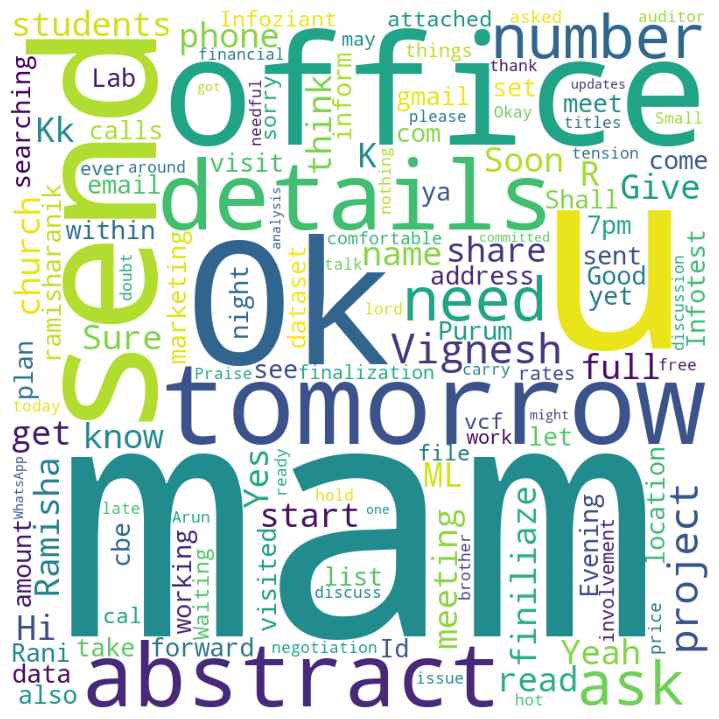

Successfully created


In [33]:
comment_words = []
stoplist = stopwords.words('english')
stoplist.extend(['omitted', 'voice','missed','call','video','deleted','media','message'])
wordcloudss="This function saves image"
dataset.index=range(dataset.shape[0])
for i in range(1,len(dataset)): 
    comment_words.append(dataset['Chat'][i])
    vv=" ".join(comment_words)          
    wordcloud = WordCloud(width = 800, height = 800, 
                                background_color ='white', 
                                      stopwords = stoplist, 
                                      min_font_size = 10).generate(vv)         
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.savefig('wordcloud.PNG')
plt.show() 
print("Successfully created")
wordcloudss="This function saves image"
